In [1]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import random
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

%matplotlib widget

In [2]:
def Linear_Fit(m, q, x):

    return m*x + q


def Sinusoidal_Fit(A, C , K, x):

    return A * np.sin(K * x + C)  

"""def sinusoid(x, A, omega, phi, C):
    
    #A: ampiezza
    #omega: frequenza angolare
    #phi: fase
    #C: offset verticale
   
    return A * np.sin(omega * x + phi) + C """

'def sinusoid(x, A, omega, phi, C):\n\n    #A: ampiezza\n    #omega: frequenza angolare\n    #phi: fase\n    #C: offset verticale\n\n    return A * np.sin(omega * x + phi) + C '

# Taratura Bilancia

In [3]:
url =  "https://unipa-my.sharepoint.com/:x:/g/personal/giorgia_marino11_you_unipa_it/IQB7ohv_c3yvQLCXvs6XVn6fAZpGUXXywyE3Rf9-oHRGMPI?download=1"
def Leggi_File_excel(url, sheet_name = 0):

    response = requests.get(url)
    response.raise_for_status()

    excel_file = BytesIO(response.content)
    df = pd.read_excel(excel_file, sheet_name = sheet_name)
    return df


In [4]:
df = Leggi_File_excel(url, 0)

print(df.head())

Massa_nominale = df["Massa nominale (g)"].to_numpy()
Massa_misurata = df["Massa misurata (g) ± 0.02 g"].to_numpy()


popt, pcov = curve_fit(Linear_Fit, Massa_nominale, Massa_misurata, p0 = [1, 0],sigma = 0.02, absolute_sigma = True)

print(popt)

perr = 3 * np.sqrt(np.diag(pcov))

print(perr)

print(f"Il coefficente angolare della taratura è il seguente:{popt[1]: .3e} +/- {perr[1]}")
x = np.linspace(0,4.5, 100)
y_fit = Linear_Fit(popt[1], popt[0],x) 

   Massa nominale (g)  Massa misurata (g) ± 0.02 g
0              0.0670                         0.06
1              0.1688                         0.15
2              0.4651                         0.45
3              0.6939                         0.68
4              0.7663                         0.76
[-0.01403222  1.00156773]
[0.0290356 0.0160143]
Il coefficente angolare della taratura è il seguente: 1.002e+00 +/- 0.016014301702673157


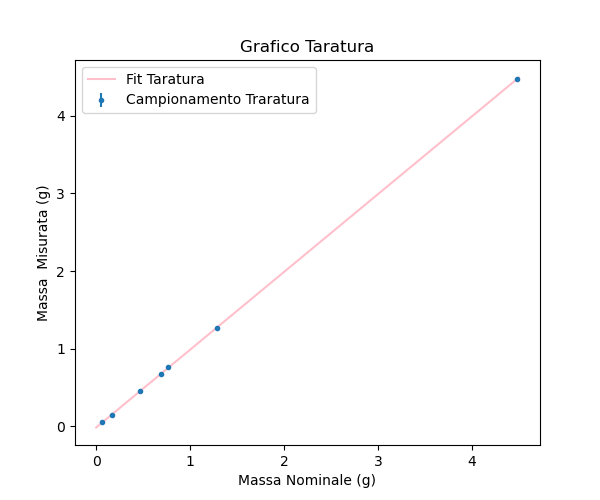

In [5]:

fig, ax = plt.subplots(figsize = (6,5))

ax.set_title("Grafico Taratura")
ax.set_xlabel("Massa Nominale (g)")
ax.set_ylabel("Massa  Misurata (g)")
ax.errorbar(Massa_nominale,Massa_misurata, yerr =0.02, fmt = ".", label = "Campionamento Traratura")
ax.plot(x, y_fit, color = "pink", label = "Fit Taratura")
ax.legend()

fig.savefig("Grafico Taratura.png", dpi = 300, bbox_inches = "tight")

# Inizio Primo Punto

In [6]:
df = Leggi_File_excel(url, 2)

df.head()

,Circuito,l (mm) ± 0.05 mm,Massa pre-Corrente (g),I Generatore (A),Massa post-Corrente (g),I amperometro
0,SF42,42.0,164.47,0.39,164.02,0.5
1,NaN,NaN,NaN,0.90,163.87,1.0
2,NaN,NaN,NaN,1.37,163.61,1.5
3,NaN,NaN,NaN,1.84,163.29,2.0
4,NaN,NaN,NaN,2.28,163.05,2.5


In [7]:
"""Errore Della Bilancia"""

Errore_Massa = 0.02

"""Converto i dati del file excel in array"""

Massa_Post_Corrente = df["Massa post-Corrente (g)"].to_numpy()
Massa_Post_Corrente = Massa_Post_Corrente[~np.isnan(Massa_Post_Corrente)]


Massa_Pre_Corrente = df["Massa pre-Corrente (g)"].to_numpy()
Massa_Pre_Corrente = Massa_Pre_Corrente[~np.isnan(Massa_Pre_Corrente)]

I_amperometro = df["I amperometro"].to_numpy()
I_amperometro = I_amperometro[~np.isnan(I_amperometro)]
#print(I_amperometro)
"""Lunghezza Circuito SF42"""

Lunghezza_Circuito = df["l (mm) ± 0.05 mm"].to_numpy()
Lunghezza_Circuito = Lunghezza_Circuito[~np.isnan(Lunghezza_Circuito)]

Errore_Delta_Massa = 0.04 
Errore_Delta_Massa /=1000

"""In grammi"""
Delta_Massa = np.abs(Massa_Post_Corrente - Massa_Pre_Corrente)

Delta_Massa/= 1000


Errore_Delta_Massa = Errore_Delta_Massa + np.std(Delta_Massa)/np.sqrt(Delta_Massa.size)

Forza_Risultante = Delta_Massa * 9.81
print(Forza_Risultante)

Lunghezza_Circuito = Lunghezza_Circuito/1000

[0.0044145 0.005886  0.0084366 0.0115758 0.0139302 0.0163827 0.0193257
 0.0222687 0.0247212]


In [8]:

#I_amperometro = np.delete(I_amperometro,0)
#Forza_Risultante = np.delete(Forza_Risultante,0)

popt, pcov = curve_fit(Linear_Fit, I_amperometro ,Forza_Risultante, sigma = 0.00004, absolute_sigma = True)

q, m = popt


m_calcolato = Forza_Risultante[-1] - Forza_Risultante[0]

m_calcolato /= I_amperometro[-1] - I_amperometro[0] 

#print(m_calcolato)

perr = 3* np.sqrt(np.diag(pcov))

Errore_m = perr[1]
"""Moltiplico per due la lunghezza del circuito, perchè il circuito percorre per 2 volte il segmento del circuito SF42"""

B_sperimentale = m/(2*Lunghezza_Circuito[0])
Errore_B_sperimentale = np.sqrt((Errore_m/m)**2 + (0.1e-3/Lunghezza_Circuito[0])**2) * B_sperimentale


print(f"B_sperimentale : {B_sperimentale: } ± {Errore_B_sperimentale: } ")

x = np.linspace(0,4.5, 100)
y_fit_5 = Linear_Fit(m, q, x)

print(f"B = ({B_sperimentale * 100: .3} ± {Errore_B_sperimentale * 100: .2}) * 10'-2")

B_sperimentale :  0.06228571426480257 ±  0.000397551423874977 
B = ( 6.23 ±  0.04) * 10'-2


Text(0.5, 1.0, 'Grafico Forza Risultante al variare di I(A)')

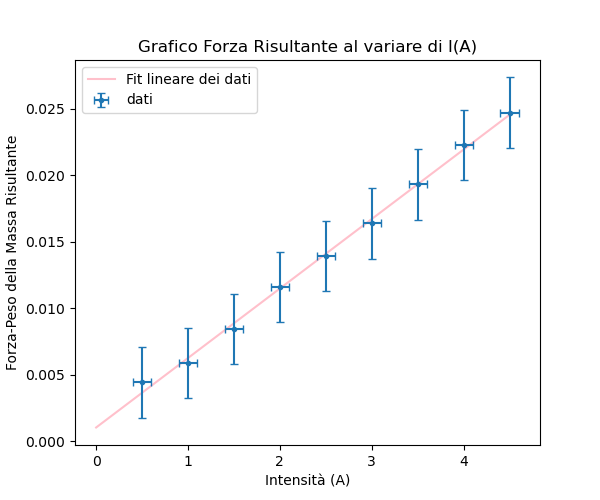

In [9]:
n = Forza_Risultante.size

fig, ax = plt.subplots(figsize = (6,5))

ax.plot(x, y_fit_5, color = "Pink", label = "Fit lineare dei dati")
ax.errorbar(I_amperometro, Forza_Risultante, yerr= Errore_Delta_Massa*9.81, xerr = 0.1, fmt = ".", capsize = 3, label = "dati" )
ax.legend()
ax.set_xlabel("Intensità (A)")
ax.set_ylabel(r'Forza-Peso della Massa Risultante') 
ax.set_title("Grafico Forza Risultante al variare di I(A)")


Errore_Forza = Errore_Delta_Massa*9.81
x = np.linspace(0,4.5, 100)
"""Retta Massima Pendenza"""
m_max = (Forza_Risultante[-1] + Errore_Forza) - (Forza_Risultante[0] - Errore_Forza)
m_max /= x[-1] - 0.45
"""Retta Minima Pendenza"""

m_min = (Forza_Risultante[-1] - Errore_Forza) - (Forza_Risultante[0] + Errore_Forza)
m_min /= x[-1] - 0.45

""" Stina di q max e min """
y_fit_1 =  Linear_Fit(m_max, 0, x)
y_fit_2 =  Linear_Fit(m_min, 0, x)
q_max = (Forza_Risultante[-1] + Errore_Forza) - y_fit_1[-1]  
q_min = (Forza_Risultante[-1] - Errore_Forza) - y_fit_2[-1]  

""" Correggo i fit del fattore q_max q_min """
y_fit_1 = y_fit_1 + q_max 
y_fit_2 = y_fit_2 + q_min

""" Ricavo i valori best e i rispettivi errori """
m_best_1 = m_max + m_min
m_best_1 /= 2

Errore_m_best_1 = m_max - m_min
Errore_m_best_1 /= 2

q_best_1 = q_max + q_min
q_best_1 /= 2

Errore_q_best_1 = np.abs(q_max - q_min)
Errore_q_best_1 /= 2

y_fit_3 =  Linear_Fit(m_best_1, q_best_1, x)

print(f"q_best: {q_best_1} ± {Errore_q_best_1}")

print(f"m_best: {m_best_1} ± {Errore_m_best_1}")
#print(y_fit_1)

B_sperimentale = m_best_1/(2*Lunghezza_Circuito[0])
Errore_B_sperimentale = np.sqrt((Errore_m_best_1/m_best_1)**2 + (0.05e-3/Lunghezza_Circuito[0])**2) * B_sperimentale

print(f"B: {B_sperimentale* 100: } ± {Errore_B_sperimentale * 100: }")

fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(I_amperometro, Forza_Risultante, yerr= Errore_Delta_Massa*9.81, xerr = 0.1, fmt = ".", capsize = 3, label = "Dati" )
ax.plot(x, y_fit_1, label = "Massima pendenza",linestyle = "--", color = "Purple")
ax.plot(x, y_fit_2, color = "pink", label = "Minima pendenza", linestyle = "--")
ax.plot(x, y_fit_3, color = "magenta", label = "Best fit", linestyle = "--")
ax.set_xlabel("Intensità (A)")
ax.set_ylabel(r'Forza-Peso della Massa Risultante') 
ax.set_title("Grafico Forza Risultante al variare di I(A)")
ax.legend()

In [10]:
df = Leggi_File_excel(url, 3)

df.head()


"""Errore Della Bilancia"""

Errore_Massa = 0.02

"""Converto i dati del file excel in array"""

Massa_Post_Corrente_1 = df["Massa post-Corrente (g)"].to_numpy()
Massa_Post_Corrente_1 = Massa_Post_Corrente_1[~np.isnan(Massa_Post_Corrente_1)]


Massa_Pre_Corrente_1 = df["Massa pre-Corrente (g)"].to_numpy()
Massa_Pre_Corrente_1 = Massa_Pre_Corrente_1[~np.isnan(Massa_Pre_Corrente_1)]

I_amperometro_1 = df["I amperometro"].to_numpy()
I_amperometro_1 = I_amperometro_1[~np.isnan(I_amperometro_1)]
#print(I_amperometro)
"""Lunghezza Circuito SF42"""

Lunghezza_Circuito_1 = df["l (mm) ± 0.05 mm"].to_numpy()
Lunghezza_Circuito_1 = Lunghezza_Circuito_1[~np.isnan(Lunghezza_Circuito_1)]

"""In g"""
Delta_Massa_1 = np.abs(Massa_Post_Corrente_1 - Massa_Pre_Corrente_1)

Delta_Massa_1/= 1000

Forza_Risultante_1 = Delta_Massa_1 * 9.81

Lunghezza_Circuito_1 = Lunghezza_Circuito_1/1000

#I_amperometro_1 = np.delete(I_amperometro_1, 2)
#Forza_Risultante_1= np.delete(Forza_Risultante,2)

In [11]:

#I_amperometro_1 = np.delete(I_amperometro_1,2)
#Forza_Risultante_1 = np.delete(Forza_Risultante_1,2)

popt, pcov = curve_fit(Linear_Fit, I_amperometro_1 ,Forza_Risultante_1, sigma = 0.00004, absolute_sigma = True)

q, m = popt



#print(m_calcolato)

perr = 3* np.sqrt(np.diag(pcov))

Errore_m_1 = perr[1]
"""Moltiplico per due la lunghezza del circuito, perchè il circuito percorre per 2 volte il segmento L6"""


B_sperimentale_1 = m/(2*Lunghezza_Circuito_1[0])
Errore_B_sperimentale_1 = np.sqrt((Errore_m_1/m)**2 + (0.1e-3/Lunghezza_Circuito_1[0])**2) * B_sperimentale_1

print(f"B_sperimentale : {B_sperimentale_1: .2} ± {Errore_B_sperimentale_1: .2}")

x = np.linspace(0,4.5, 100)
y_fit_4 = Linear_Fit(m, q, x) 

B_sperimentale :  0.064 ±  0.0004


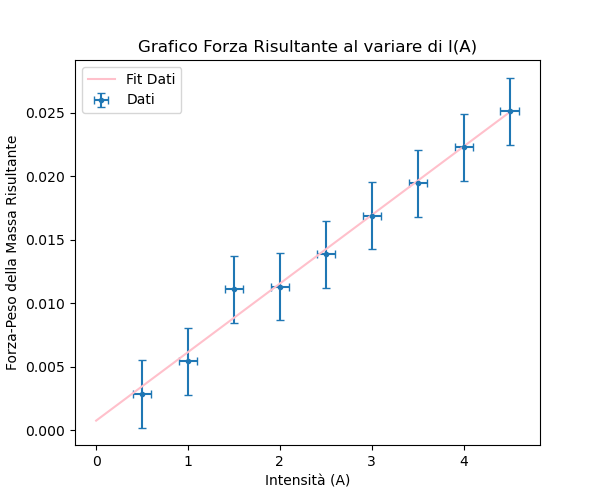

In [12]:

fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(I_amperometro_1, Forza_Risultante_1, yerr= Errore_Delta_Massa*9.81, xerr = 0.1, fmt = ".", capsize = 3, label = "Dati" )
ax.plot(x, y_fit_4, color = "pink", label = "Fit Dati")
ax.set_xlabel("Intensità (A)")
ax.set_ylabel(r'Forza-Peso della Massa Risultante') 
ax.set_title("Grafico Forza Risultante al variare di I(A)")
ax.legend()

Errore_Forza = Errore_Delta_Massa*9.81

x = np.linspace(0,4.5, 100)
"""Retta Massima Pendenza"""
m_max = (Forza_Risultante_1[-1] + Errore_Forza) - (Forza_Risultante_1[0] - Errore_Forza)
m_max /= x[-1] - 0.45
"""Retta Minima Pendenza"""

m_min = (Forza_Risultante_1[-1] - Errore_Forza) - (Forza_Risultante_1[0] + Errore_Forza)
m_min /= x[-1] - 0.45

""" Stina di q max e min """
y_fit_1 =  Linear_Fit(m_max, 0, x)
y_fit_2 =  Linear_Fit(m_min, 0, x)
q_max = (Forza_Risultante_1[-1] + Errore_Forza) - y_fit_1[-1]  
q_min = (Forza_Risultante_1[-1] - Errore_Forza) - y_fit_2[-1]  

""" Correggo i fit del fattore q_max q_min """
y_fit_1 = y_fit_1 + q_max 
y_fit_2 = y_fit_2 + q_min

""" Ricavo i valori best e i rispettivi errori """
m_best_2 = m_max + m_min
m_best_2 /= 2

Errore_m_best_2 = m_max - m_min
Errore_m_best_2 /= 2

q_best_2 = q_max + q_min
q_best_2 /= 2

Errore_q_best_2 = np.abs(q_max - q_min)
Errore_q_best_2 /= 2

y_fit_3 =  Linear_Fit(m_best_2, q_best_2, x)

print(f"q_best: {q_best_2} ± {Errore_q_best_2}")

print(f"m_best: {m_best_2} ± {Errore_m_best_2}")
#print(y_fit_1)

B_sperimentale_1 = m_best_1/(2*Lunghezza_Circuito_1[0])
Errore_B_sperimentale_1 = np.sqrt((Errore_m_best_2/m_best_2)**2 + (0.05e-3/Lunghezza_Circuito_1[0])**2) * B_sperimentale_1

print(f"B: {B_sperimentale_1* 100: } ± {Errore_B_sperimentale_1 * 100: }")

fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(I_amperometro_1, Forza_Risultante_1, yerr= Errore_Delta_Massa*9.81, xerr = 0.1, fmt = ".", capsize = 3, label = "Dati" )
ax.plot(x, y_fit_1, label = "Fit Dati",linestyle = "--", color = "Purple")
ax.plot(x, y_fit_2, color = "pink", label = "Fit Dati", linestyle = "--")
ax.plot(x, y_fit_3, color = "magenta", label = "Fit Dati", linestyle = "--")
ax.set_xlabel("Intensità (A)")
ax.set_ylabel(r'Forza-Peso della Massa Risultante') 
ax.set_title("Grafico Forza Risultante al variare di I(A)")
ax.legend()

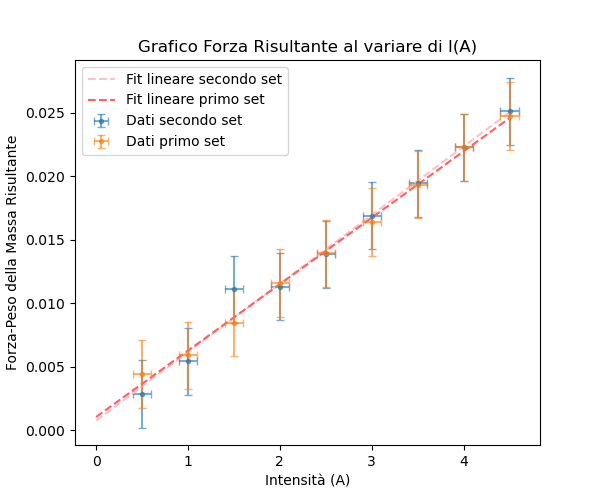

In [13]:

fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(I_amperometro_1, Forza_Risultante_1, yerr= Errore_Delta_Massa*9.81, xerr = 0.1, fmt = ".", capsize = 3, label = "Dati secondo set", alpha = 0.6 )
ax.plot(x, y_fit_4, color = "pink", label = "Fit lineare secondo set", linestyle = "--")
ax.set_xlabel("Intensità (A)")
ax.set_ylabel(r'Forza-Peso della Massa Risultante') 
ax.set_title("Grafico Forza Risultante al variare di I(A)")
ax.plot(x, y_fit_5, color = "#ff6060", label = "Fit lineare primo set", linestyle = "--")
ax.errorbar(I_amperometro, Forza_Risultante, yerr= Errore_Delta_Massa*9.81, xerr = 0.1, fmt = ".", capsize = 3, label = "Dati primo set", alpha = 0.6 )
ax.set_xlabel("Intensità (A)")
ax.set_ylabel(r'Forza-Peso della Massa Risultante') 
ax.set_title("Grafico Forza Risultante al variare di I(A)")
ax.legend()

fig.savefig("Grafico Forza Risultante al Variare di I dei due set(post modifica).png", dpi = 300, bbox_inches = "tight")

# Inizio Secondo Punto

In [14]:
df = Leggi_File_excel( url , 4)

print(df.head())

   I(A) Circuito  l (mm) ± 0.05 mm   Massa
0   4.0     SF37             22.20  163.85
1   NaN     SF38             42.00  163.28
2   NaN     SF39             32.20  163.57
3   NaN     SF40             11.85  164.16
4   NaN     SF41             32.00  162.76


In [15]:
Intensita_Fissa = df["I(A)"].to_numpy()
Lunghezze = df["l (mm) ± 0.05 mm"].to_numpy()
Massa_Post_Corrente = df["Massa"].to_numpy()

""" ~ = Alt + 126 """
Intensita_Fissa = Intensita_Fissa[~np.isnan(Intensita_Fissa)]
Lunghezze = Lunghezze[~np.isnan(Lunghezze)]
Massa_Post_Corrente = Massa_Post_Corrente[~np.isnan(Massa_Post_Corrente)]

""" Corrego le unità di misura""" 

Lunghezze/= 1000

""" Come Per SF42 Il circuito attraversa 2 volte il magnete dunque è 2 volte il valore misurato"""

Lunghezze[-2] *= 2
Lunghezze[-1] *= 2

"""Forza Risultante"""

Delta_Masse = np.abs(Massa_Post_Corrente - Massa_Pre_Corrente_1)
Delta_Masse /= 1000

Forza_Risultante_2 = Delta_Masse * 9.81


In [16]:
popt, pcov = curve_fit(Linear_Fit, Lunghezze ,Forza_Risultante_2, sigma = 0.00004, absolute_sigma = True)

q, m = popt



#print(m_calcolato)

perr = 3* np.sqrt(np.diag(pcov))

Errore_m = perr[1]
"""Moltiplico per due la lunghezza del circuito, perchè il circuito percorre per 2 volte il segmento L6"""


B_sperimentale_2 = m/(Intensita_Fissa[0])
Errore_B_sperimentale_2 = np.sqrt((Errore_m/m)**2 + (0.1/Intensita_Fissa[0])**2) * B_sperimentale_2

print(f"B_sperimentale : {B_sperimentale_2: .2} ± {Errore_B_sperimentale_2: .2}")

x = np.linspace(0.01, 0.085,100)

y_fit_3 = Linear_Fit(m, q, x) 

B_sperimentale :  0.066 ±  0.0017


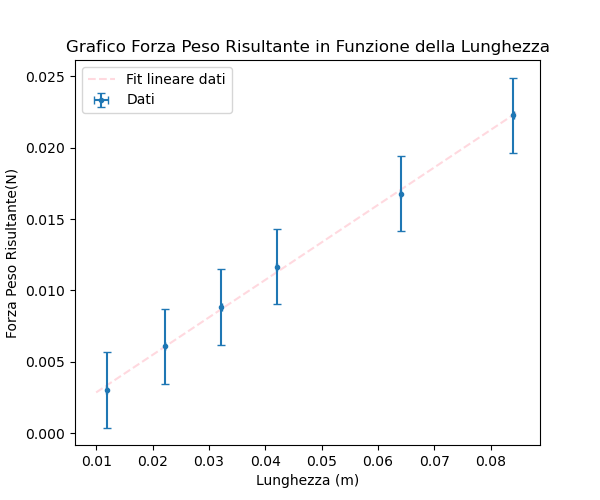

In [17]:
fig, ax = plt.subplots(figsize = (6,5))

ax.plot(x, y_fit_3, color = "pink", alpha = 0.6, linestyle = "--", label = "Fit lineare dati")
ax.errorbar(Lunghezze, Forza_Risultante_2, xerr = 0.05e-3, yerr = Errore_Delta_Massa * 9.81, fmt = ".", capsize = 3, label = "Dati" )
ax.set_xlabel("Lunghezza (m)")
ax.set_ylabel("Forza Peso Risultante(N)")
ax.set_title("Grafico Forza Peso Risultante in Funzione della Lunghezza")
ax.legend()
fig.savefig("Grafico Forza Risultante al Variare della Lunghezza.png", dpi = 300, bbox_inches = "tight")


Errore_Forza = Errore_Delta_Massa*9.81

x = np.linspace(Lunghezze[3],0.09, 100)
"""Retta Massima Pendenza"""
m_max = (Forza_Risultante_2[-1] + Errore_Forza) - (Forza_Risultante_2[0] - Errore_Forza)
m_max /= x[-1] - x[0]
"""Retta Minima Pendenza"""

m_min = (Forza_Risultante_2[-1] - Errore_Forza) - (Forza_Risultante_2[0] + Errore_Forza)
m_min /= x[-1] - x[0]

""" Stina di q max e min """
y_fit_1 =  Linear_Fit(m_max, 0, x)
y_fit_2 =  Linear_Fit(m_min, 0, x)
q_max = (Forza_Risultante_2[-1] + Errore_Forza) - y_fit_1[-1]  
q_min = (Forza_Risultante_2[-1] - Errore_Forza) - y_fit_2[-1]  

""" Correggo i fit del fattore q_max q_min """
y_fit_1 = y_fit_1 + q_max 
y_fit_2 = y_fit_2 + q_min

""" Ricavo i valori best e i rispettivi errori """
m_best_3 = m_max + m_min
m_best_3 /= 2

Errore_m_best_3 = m_max - m_min
Errore_m_best_3 /= 2

q_best_3 = q_max + q_min
q_best_3 /= 2

Errore_q_best_3 = np.abs(q_max - q_min)
Errore_q_best_3 /= 2

y_fit_3 =  Linear_Fit(m_best_3, q_best_3, x)

print(f"q_best: {q_best_3} ± {Errore_q_best_3}")

print(f"m_best: {m_best_3} ± {Errore_m_best_3}")
#print(y_fit_1)

B_sperimentale_2 = m_best_3/(Intensita_Fissa[0])
Errore_B_sperimentale_2 = np.sqrt((Errore_m_best_2/m_best_2)**2 +(0.1/Intensita_Fissa[0])**2) * B_sperimentale_2

print(f"B: {B_sperimentale_2* 100: } ± {Errore_B_sperimentale_2 * 100: }")"""

fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(Lunghezze, Forza_Risultante_2, yerr= Errore_Delta_Massa*9.81, fmt = ".", capsize = 3, label = "Dati" )
ax.plot(x, y_fit_1, label = "Massima Pendenza",linestyle = "--", color = "Purple")
ax.plot(x, y_fit_2, color = "pink", label = "Minima Pendenza", linestyle = "--")
ax.plot(x, y_fit_3, color = "magenta", label = "Best Fit", linestyle = "--")
ax.set_xlabel("Intensità (A)")
ax.set_ylabel(r'Forza-Peso della Massa Risultante') 
ax.set_title("Grafico Forza Risultante al variare di I(A)")
ax.legend()

In [18]:
plt.close()

Intensita_Fissa = 2
Massa_Pre_Corrente = 104.78

# Inizio Terzo Punto

In [19]:
df = Leggi_File_excel( url , 6)

print(df.head())


Theta_0 = df["Angolo ± 1 grado"].to_numpy()

Masse = df["Massa"].to_numpy()

Delta_Masse = Masse - Massa_Pre_Corrente

Delta_Masse /= 1000
print(Delta_Masse)

Errore_Delta_Massa_1 = 0.04/1000 + np.std(Delta_Masse)/np.sqrt(Delta_Masse.size)
"""Processo di Collage """

Theta_0 = Theta_0 - 2

""" Converto in Radianti i dati"""

Theta_0 = np.pi* Theta_0/180
Errore_Theta =  np.pi/180 
#print(Theta_0)

   I(A)  Angolo ± 1 grado   Massa
0   2.0               -90  105.16
1   NaN               -80  105.15
2   NaN               -70  105.14
3   NaN               -60  105.13
4   NaN               -50  105.11
[ 3.8e-04  3.7e-04  3.6e-04  3.5e-04  3.3e-04  3.0e-04  2.4e-04  1.7e-04
  1.2e-04  2.0e-05 -3.0e-05 -8.0e-05 -1.5e-04 -2.1e-04 -2.6e-04 -2.9e-04
 -3.5e-04 -3.8e-04 -4.0e-04]


<ErrorbarContainer object of 3 artists>

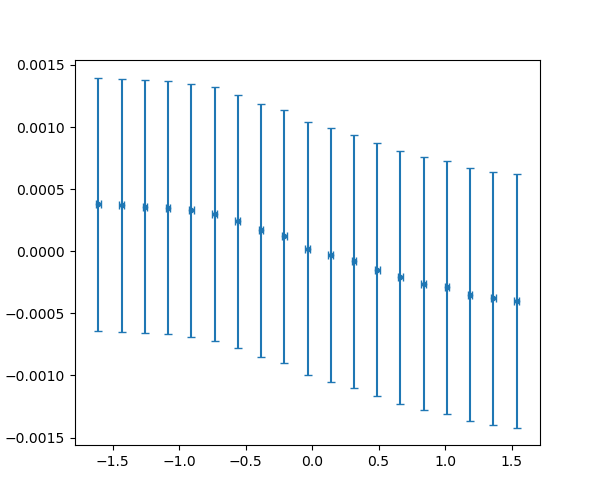

In [20]:
fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(Theta_0, Delta_Masse, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1 * 9.81 , fmt = ".", capsize = 3)

   I(A)  Angolo ± 1 grado   Massa
0   2.0               -90  104.83
1   NaN               -80  104.73
2   NaN               -70  104.68
3   NaN               -60  104.61
4   NaN               -50  104.56
[ 3.8e-04  3.7e-04  3.6e-04  3.5e-04  3.3e-04  3.0e-04  2.4e-04  1.7e-04
  1.2e-04  2.0e-05 -3.0e-05 -8.0e-05 -1.5e-04 -2.1e-04 -2.6e-04 -2.9e-04
 -3.5e-04 -3.8e-04 -4.0e-04]


<ErrorbarContainer object of 3 artists>

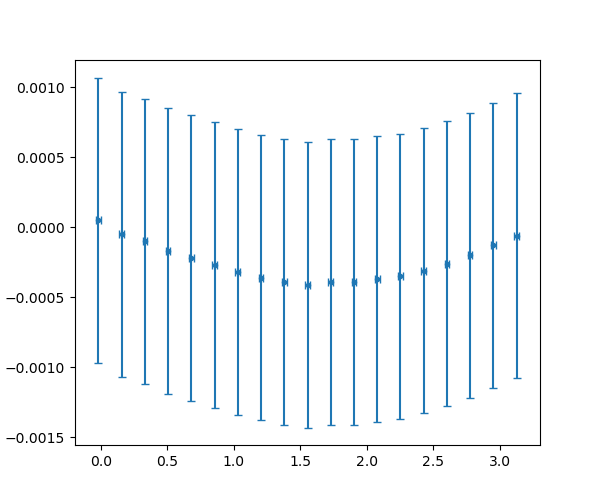

In [21]:
df = Leggi_File_excel( url , 7)

print(df.head())


Theta_1 = df["Angolo ± 1 grado"].to_numpy()

Masse = df["Massa"].to_numpy()

Delta_Masse_1 = Masse - Massa_Pre_Corrente

Delta_Masse_1 /= 1000
print(Delta_Masse)
""" Correzzione di Collage"""

Theta_1 = Theta_1 + 89

""" Converto in Radianti i dati"""

Theta_1 = np.pi* Theta_1/180
Errore_Theta =  np.pi/180 
#print(Theta_1)

""" Plotto i dati"""
fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(Theta_1, Delta_Masse_1, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1 * 9.81 , fmt = ".", capsize = 3)

   I(A)  Angolo ± 1 grado   Massa
0   2.0                 0  104.72
1   NaN                10  104.79
2   NaN                20  104.86
3   NaN                30  104.92
4   NaN                40  104.98
[-6.0e-05  1.0e-05  8.0e-05  1.4e-04  2.0e-04  2.6e-04  3.1e-04  3.4e-04
  3.7e-04  3.8e-04]
[3.10668607 3.28121899 3.45575192 3.63028484 3.80481777 3.97935069
 4.15388362 4.32841654 4.50294947 4.6774824 ]


<ErrorbarContainer object of 3 artists>

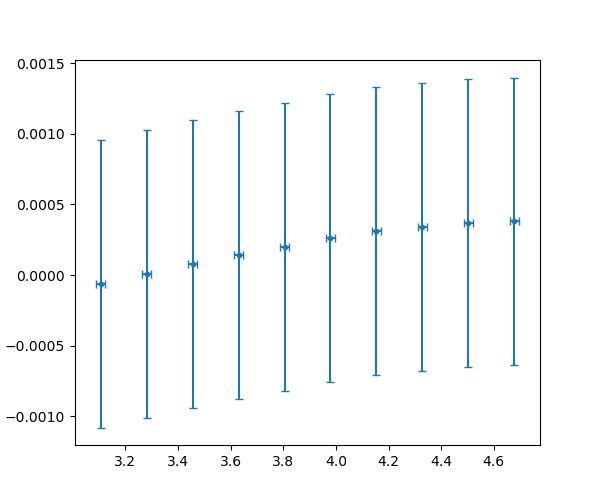

In [22]:
df = Leggi_File_excel( url , 8)

print(df.head())


Theta_2 = df["Angolo ± 1 grado"].to_numpy()

Masse = df["Massa"].to_numpy()

Delta_Masse_2 = Masse - Massa_Pre_Corrente

Delta_Masse_2 /= 1000
print(Delta_Masse_2)


""" Converto in Radianti i dati"""
""" Processo di Collage"""
Theta_2 = Theta_2 + 178

Theta_2 = np.pi* Theta_2/180
Errore_Theta =  np.pi/180 
print(Theta_2)

""" Plotto i dati"""
fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(Theta_2, Delta_Masse_2, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1 * 9.81 , fmt = ".", capsize = 3)

   I(A)  Angolo ± 1 grado   Massa
0   2.0               -90  104.77
1   NaN               -80     NaN
2   NaN               -70  104.90
3   NaN               -60  104.97
4   NaN               -50  105.04
[-1.0e-05  1.2e-04  1.9e-04  2.6e-04  3.0e-04  3.5e-04  4.1e-04  4.3e-04]
[-182 -162 -152 -142 -132 -122 -102  -92]
[-3.17649924 -2.82743339 -2.65290046 -2.47836754 -2.30383461 -2.12930169
 -1.78023584 -1.60570291]


<ErrorbarContainer object of 3 artists>

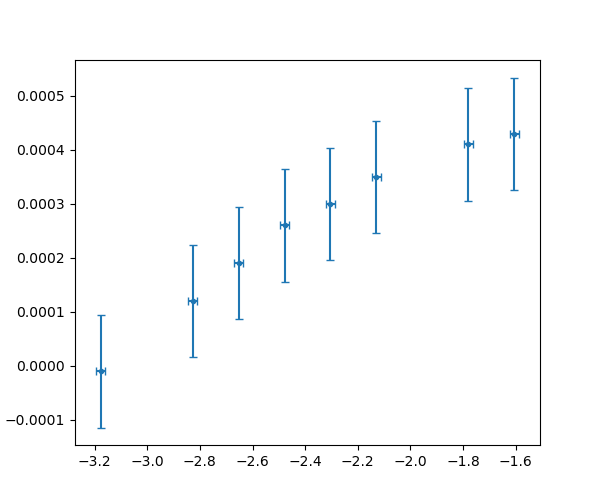

In [23]:
df = Leggi_File_excel( url , 9)

print(df.head())


Theta_3 = df["Angolo ± 1 grado"].to_numpy()

Masse = df["Massa"].to_numpy()
Masse = Masse[~np.isnan(Masse)]

Delta_Masse_3 = Masse - Massa_Pre_Corrente

Delta_Masse_3 /= 1000
print(Delta_Masse_3)


""" Converto in Radianti i dati"""
""" Processo di Collage"""
Theta_3 = Theta_3 - 92

Theta_3 = np.delete(Theta_3, 1, axis = 0)

Theta_3 = np.delete(Theta_3, 6)
print(Theta_3)

Theta_3 = np.pi* Theta_3/180
Errore_Theta =  np.pi/180 
print(Theta_3)

""" Plotto i dati"""
fig, ax = plt.subplots(figsize = (6,5))

ax.errorbar(Theta_3, Delta_Masse_3, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1 , fmt = ".", capsize = 3)

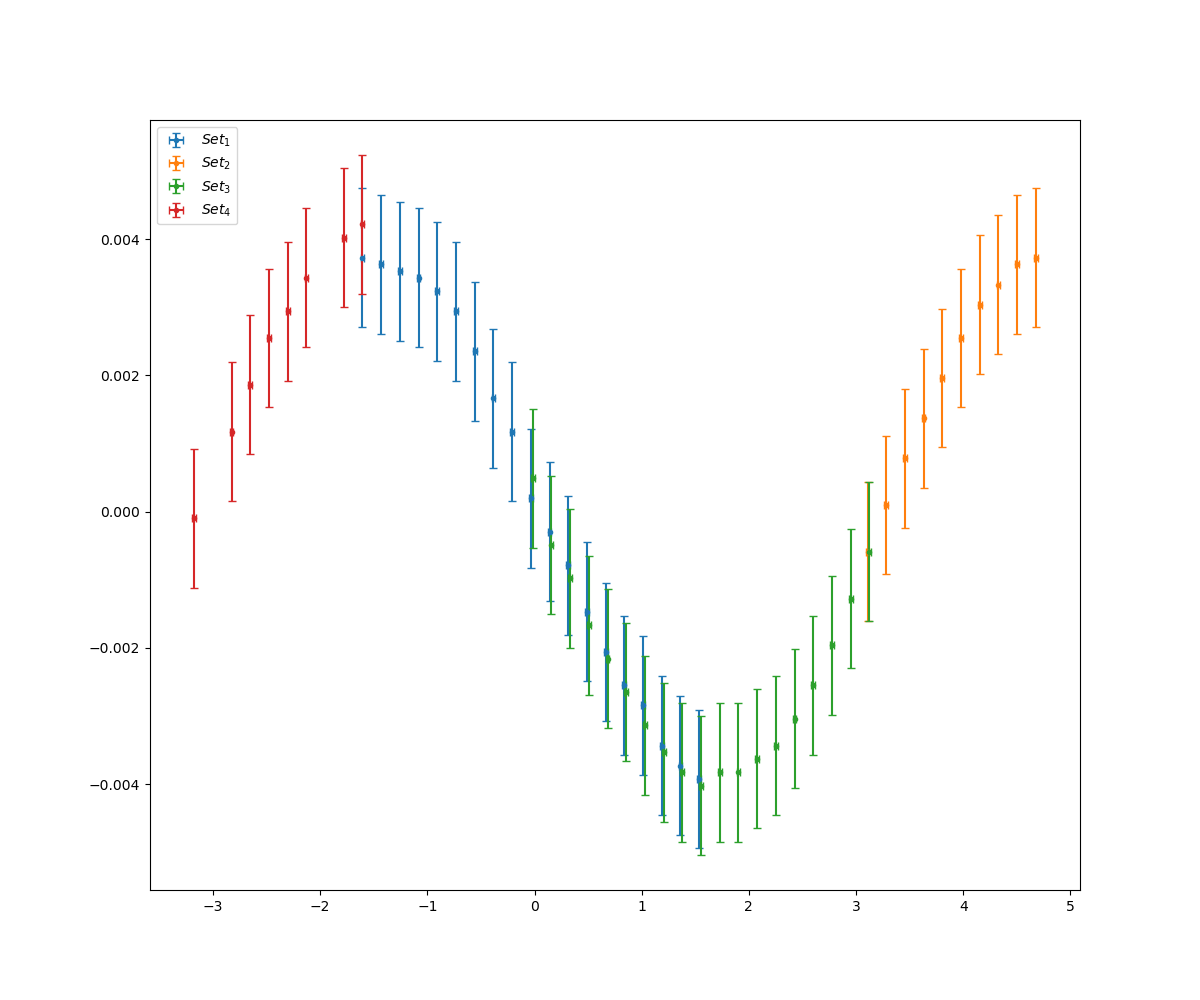

In [24]:
fig, ax = plt.subplots(figsize = (12,10))

ax.errorbar(Theta_0, Delta_Masse * 9.81, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_1$')
ax.errorbar(Theta_2, Delta_Masse_2  * 9.81, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_2$')
ax.errorbar(Theta_1, Delta_Masse_1  * 9.81, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_3$')
ax.errorbar(Theta_3, Delta_Masse_3 * 9.81, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_4$')
ax.legend()

# Fit Sinusoidale Test

List = [Theta_3, Theta_0, Theta_1, Theta_2]

Thetas = np.concatenate(List , axis = 0)
Thetas = Thetas + np.abs(Thetas[0])


Masse = np.concatenate([Delta_Masse_3, Delta_Masse, Delta_Masse_1, Delta_Masse_2], axis = 0)

Delta_Forza_1 = Delta_Masse * 9.81
Delta_Forza_2 = Delta_Masse_1 * 9.81
Delta_Forza_3 = Delta_Masse_2 * 9.81
Delta_Forza_4 = Delta_Masse_3 * 9.81



List = [Delta_Forza_4, Delta_Forza_1, Delta_Forza_2, Delta_Forza_3]


Forze = np.concatenate(List, axis = 0)


Forze = Forze[~np.isnan(Forze)]

#print(Forze)

#print(f"Dimensione di Forze: {Forze.size}\nDimensione di Thetas: {Thetas.size}")
    
popt, pcov = curve_fit(Sinusoidal_Fit, Thetas ,Forze)
  
x = np.linspace(0, Thetas[-1], 100)
y_fit_4 = Sinusoidal_Fit(np.abs(popt[1]), popt[0], x)
y_fit_4 -= popt[0]
#print(f"Forze: {Forze}\nAngoli:{Thetas}")
print(popt * 9.81)

fig, ax = plt.subplots(figsize = (6,5))

ax.plot(x, y_fit_4)
ax.errorbar(Thetas, Masse, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1, fmt = ".", capsize = 3, label = r'$Set_1$')

In [26]:
Delta_Forza_1 = Delta_Masse * 9.81
Delta_Forza_2 = Delta_Masse_1 * 9.81
Delta_Forza_3 = Delta_Masse_2 * 9.81 
Delta_Forza_4 = Delta_Masse_3 * 9.81


Delta_Forza_1_min = Delta_Forza_1 - np.abs(Errore_Delta_Massa_1 * 9.81)
Delta_Forza_2_min = Delta_Forza_2 - np.abs(Errore_Delta_Massa_1 * 9.81)
Delta_Forza_3_min = Delta_Forza_3 - np.abs(Errore_Delta_Massa_1 * 9.81)
Delta_Forza_4_min = Delta_Forza_4 - np.abs(Errore_Delta_Massa_1 * 9.81)

Delta_Forza_1_max = Delta_Forza_1 + np.abs(Errore_Delta_Massa_1 * 9.81)
Delta_Forza_2_max = Delta_Forza_2 + np.abs(Errore_Delta_Massa_1 * 9.81)
Delta_Forza_3_max = Delta_Forza_3 + np.abs(Errore_Delta_Massa_1 * 9.81)
Delta_Forza_4_max = Delta_Forza_4 + np.abs(Errore_Delta_Massa_1 * 9.81)

Delta_Forza_1_min[0] = (Delta_Forza_1_min[0] + Delta_Forza_4_min[-1])/2

Delta_Forza_3_min[0] = (Delta_Forza_3_min[0] + Delta_Forza_2_min[-1])/2

Delta_Forza_1_min_slaced = (Delta_Forza_1_min[9:] + Delta_Forza_2_min[0:10])/2

List = [Delta_Forza_1_min[0], Delta_Forza_1_min[1:10], Delta_Forza_1_min_slaced, Delta_Forza_2_min[9:]] 
Delta_Forze_minime = Delta_Forza_4_min[:-1]
for i in List:

    Delta_Forze_minime = np.append(Delta_Forze_minime, i)

#print(Delta_Forze_minime)
""" Lavoro analogo per le Forze Massime"""
Delta_Forza_1_max[0] = (Delta_Forza_1_max[0] + Delta_Forza_4_max[-1])/2

Delta_Forza_3_max[0] = (Delta_Forza_3_max[0] + Delta_Forza_2_max[-1])/2

Delta_Forza_1_max_slaced = (Delta_Forza_1_max[9:] + Delta_Forza_2_max[0:10])/2

List = [Delta_Forza_1_max[0], Delta_Forza_1_max[1:10], Delta_Forza_1_max_slaced, Delta_Forza_2_max[9:]] 
Delta_Forze_massime = Delta_Forza_4_max[:-1]
for i in List:

    Delta_Forze_massime = np.append(Delta_Forze_massime, i)



List = [Theta_3, Theta_0, Theta_1, Theta_2]

Thetas = np.concatenate(List , axis = 0)
Thetas = Thetas + np.abs(Thetas[0])

List = [Delta_Forza_4_max, Delta_Forza_1_max, Delta_Forza_2_max, Delta_Forza_3_max]

Forze_Massime = np.concatenate(List, axis =0)


#Forze_Massime = np.delete(Forze_Massime, 6)
#Thetas = np.delete(Thetas, 7)

print(Forze_Massime)

Forze_Massime = Forze_Massime - np.abs(Forze_Massime[0])

popt, pcov = curve_fit(sinusoid, Thetas ,Forze_Massime)

print(popt )
x = np.linspace(0, Thetas[-1], 100)
#y_fit_5 = Sinusoidal_Fit(popt[0], x)
 

fig, ax = plt.subplots(figsize = (6,5))


ax.plot(x, y_fit_5 , color = "pink", linestyle = "--")
#ax.fill_between(x, y_fit_4 * 9.81 + Errore_max, y_fit_4 * 9.81 - Errore_min, color = "#00ffff", alpha = 0.2)
ax.errorbar(Thetas, Forze_Massime, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_1$')

ax.set_xlabel(r'$\theta$(rad)')
ax.set_ylabel(r'Forza di Ampere$(N)$')
ax.set_title("Grafico andamento sinusoidale")

ax.legend()

fig, ax = plt.subplots(figsize = (6,5))

ax.plot(x, y_fit_4, color = "pink", linestyle = "--")
ax.fill_between(x, y_fit_4  + Errore_max, y_fit_4  - Errore_min, color = "#00ffff", alpha = 0.2)
ax.errorbar(Theta_0 + np.abs(Theta_3[0]), Delta_Forza_1, xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_1$')
ax.errorbar(Theta_2 + np.abs(Theta_3[0]), Delta_Forza_3 , xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_2$')
ax.errorbar(Theta_1 + np.abs(Theta_3[0]), Delta_Forza_2 , xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_3$')
ax.errorbar(Theta_3 + np.abs(Theta_3[0]), Delta_Forza_4 , xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_4$')
ax.set_xlabel(r'$\theta$(rad)')
ax.set_ylabel(r'Forza di Ampere$(N)$')
ax.set_title("Grafico andamento sinusoidale")

ax.legend()
fig.savefig("Grafico dell'andamento Sinusoidale.png", dpi = 300, bbox_inches = "tight")

"""Lunghezza della spira Complessivamente"""

Lunghezza_spira = 11.4e-2 
"""Intensita' Fissa"""

Amperaggio = 2
"""Errori strumenti"""
Errore_Lunghezza = 0.1e-3
Errore_Amperaggio = 0.1
Errore_C ,Errore_Ampiezza = np.sqrt(np.diag(pcov))*3

""" Ampiezza """

A = popt[1] 

A *= 9.81
B_Sperimentale_3 =np.abs(A/(Lunghezza_spira* Amperaggio))

Errore_B_Sperimentale_3 = np.sqrt((Errore_Amperaggio/Amperaggio)**2 + (Errore_Lunghezza/Lunghezza_spira)**2 + (Errore_Ampiezza/A)**2) * B_Sperimentale_3

print(f"B: {B_Sperimentale_3:.3} ± {Errore_B_Sperimentale_3:.3}")


# Campi Magneti a confronto

In [ ]:
B_sperimentali = [B_sperimentale, B_sperimentale_1, B_sperimentale_2]

Errori_di_B_sperimentali = [Errore_B_sperimentale, Errore_B_sperimentale_1, Errore_B_sperimentale_2]
Nomi = [r'$B(A)_{Primo\  punto}$', r'$B(A)_{Ripetizione\ primo\ punto}$', r'$B(L)_{Secondo\ punto}$']

fig, ax = plt.subplots(figsize = (6,5))
#, B_Sperimentale_3 , Errore_B_Sperimentale_3, r'$B(\theta)_{Terzo punto}$'
ax.set_ylabel(r'Tesla$(T)$')
ax.set_title(r'Grafico Confronti dei B stimati nei vari punti')
ax.errorbar(Nomi, B_sperimentali, yerr = Errori_di_B_sperimentali, fmt = '.', color = "red", capsize = 3)
fig.savefig("Grafico Confronti dei B stimati nei vari punti(non compatibili).png", dpi = 300, bbox_inches = "tight")

# Stima di A nel Terzo Punto

In [34]:
print(Delta_Forza_1_min[0])
print(Delta_Forza_1_max[0])
"""Parametri Utili"""
Lunghezza_spira = 11.4e-2 
Amperaggio = 2 
"""Errori strumenti""" 
Errore_Lunghezza = 0.1e-3 
Errore_Amperaggio = 0.1

0.0029539134146671043
0.004992186585332779


20.382731706656745
0.0040789634146672134
0.004117236585332887
0.004098100000000051
0.001019136585332837


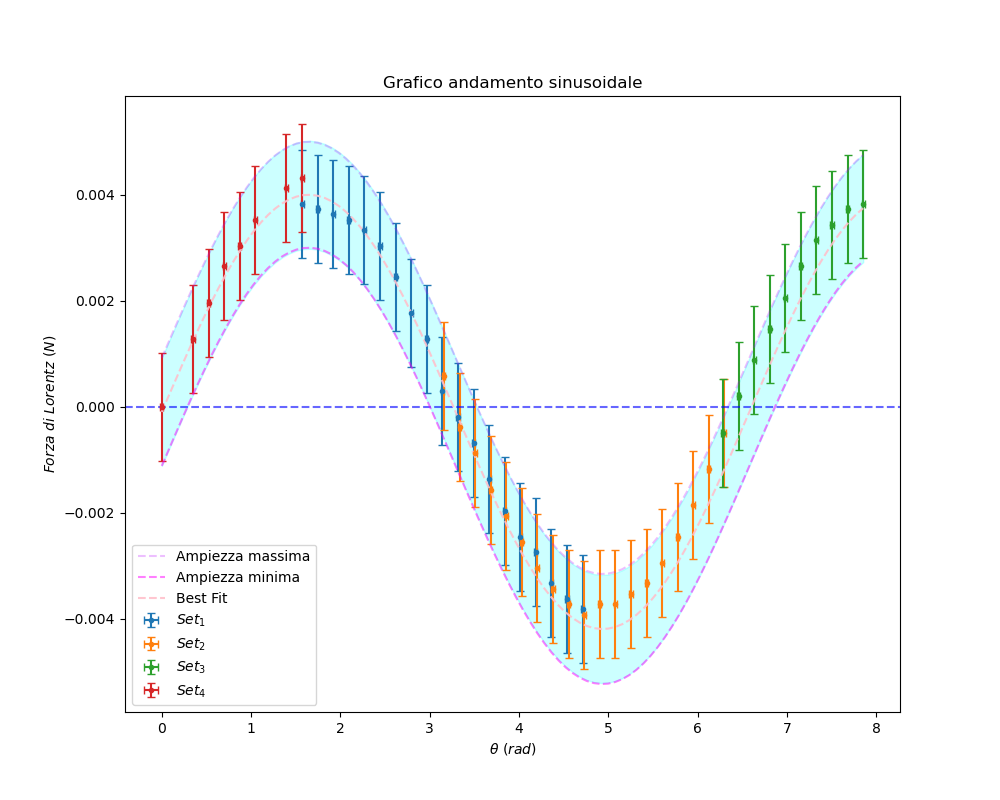

In [38]:
Delta_Forza_1 = Delta_Masse * 9.81
Delta_Forza_2 = Delta_Masse_1 * 9.81
Delta_Forza_3 = Delta_Masse_2 * 9.81
Delta_Forza_4 = Delta_Masse_3 * 9.81


List = [Delta_Forza_4, Delta_Forza_1, Delta_Forza_2, Delta_Forza_3]


Forze = np.concatenate(List, axis = 0)


Forze = Forze[~np.isnan(Forze)]

List = [Theta_3, Theta_0, Theta_1, Theta_2]

Thetas = np.concatenate(List , axis = 0)
Thetas = Thetas + np.abs(Thetas[0])

Errore_Forze = Errore_Delta_Massa_1* 9.81
x= np.linspace(0, Thetas[-1], 100)

Forze_Offset = Forze - Forze[0]

A_max = Delta_Forza_1_max[0]

A_0 = A_max

A_min = Delta_Forza_1_min[0]

#y_fit_i = Sinusoidal_Fit(A_0, 0, x)


fig, ax = plt.subplots(figsize = (10,8))
C = 0
incremento = 0.0001
N = int((A_max- A_min)/incremento)
print((A_max- A_min)/incremento)
ax.errorbar(Theta_0 + np.abs(Theta_3[0]), Delta_Forza_1 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_1$')
ax.errorbar(Theta_1 + np.abs(Theta_3[0]), Delta_Forza_2 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_2$')
ax.errorbar(Theta_2 + np.abs(Theta_3[0]), Delta_Forza_3 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_3$')
ax.errorbar(Theta_3 + np.abs(Theta_3[0]), Delta_Forza_4 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_4$')
"""
for i in range(0,N):

    

    y_fit_i = Sinusoidal_Fit(A_0, C, x )

    A_0 -= incremento
    C += incremento/2

    
    ax.plot(x, y_fit_i, linestyle = "--", alpha = 0.5)
"""

intercetta_1 = Forze[0] + Errore_Forze
A_max = 0.005 - np.abs(intercetta_1)
C = -0
K = 0.955
y_fit_i = Sinusoidal_Fit(A_max, C, K,x ) + intercetta_1
ax.plot(x, y_fit_i, linestyle = "--", alpha = 0.25, color = "#bb00ff", label = "Ampiezza massima")
ax.axhline(0, linestyle='--', color='blue', alpha = 0.6) 

ax.set_title("Grafico andamento sinusoidale")

intercetta_2 = Forze[0] - Errore_Forze
A_min = 0.003 + np.abs(intercetta_2)
y_fit_i = Sinusoidal_Fit(A_min, C, K,x ) + intercetta_2
ax.plot(x, y_fit_i, linestyle = "--", alpha = 0.5, color = "#ff00ff", label = "Ampiezza minima")

intercetta_3 = (intercetta_2 + intercetta_1)/2.
Errore_intercetta_3 = (intercetta_1 - intercetta_2)/2
A_best = (A_max + A_min)/2
Errore_A_best = (A_max - A_best)/2
print(A_max)
print(A_min)
print(A_best)
print(Errore_intercetta_3)
y_fit_i = Sinusoidal_Fit(A_best, C, K,x ) + intercetta_3
ax.plot(x, y_fit_i, linestyle = "--", alpha = 0.9, label = 'Best Fit', color = "pink")
ax.legend()
ax.set_ylabel(r'$Forza\ di\ Lorentz\ (N)$')
ax.set_xlabel(r'$\theta\ (rad)$')
ax.fill_between(x, y_fit_i  + Errore_intercetta_3, y_fit_i  - Errore_intercetta_3, color = "#00ffff", alpha = 0.2)

fig.savefig("Grafico dell'andamento Sinusoidale.png", dpi= 300, bbox_inches = "tight")

In [36]:
B_Sperimentale_3 =np.abs(A_best/(Lunghezza_spira* Amperaggio))

Errore_B_Sperimentale_3 = np.sqrt((Errore_Amperaggio/Amperaggio)**2 + (Errore_Lunghezza/Lunghezza_spira)**2 + (Errore_intercetta_3/A_best)**2) * B_Sperimentale_3

print(f"B: {B_Sperimentale_3:.3} ± {Errore_B_Sperimentale_3:.2}")


B: 0.018 ± 0.0046


In [37]:
""" Dichiaro il riquadretto della figura"""
"""
axins = inset_axes(
    ax,
    width=2, height=1,
    bbox_to_anchor=(0.25, 0.10),  # spostato fuori a destra
    bbox_transform=ax.transAxes,
    loc='center left',
    borderpad=0
)
"""

"""
# Stesso grafico dentro l'inset
axins.errorbar(Theta_0 + np.abs(Theta_3[0]), Delta_Forza_1 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_1$')
axins.errorbar(Theta_1 + np.abs(Theta_3[0]), Delta_Forza_2 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_2$')
axins.errorbar(Theta_2 + np.abs(Theta_3[0]), Delta_Forza_3 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_3$')
axins.errorbar(Theta_3 + np.abs(Theta_3[0]), Delta_Forza_4 - Forze[0], xerr = Errore_Theta, yerr = Errore_Delta_Massa_1* 9.81 , fmt = ".", capsize = 3, label = r'$Set_4$')

for i in range(0,N):

    

    y_fit_i = Sinusoidal_Fit(A_0, C, x )

    A_0 -= incremento
    C += incremento/2

    
    ax.plot(x, y_fit_i, linestyle = "--", alpha = 0.5)
"""
"""
intercetta_1 = Forze[0] + Errore_Forze
A_max = 0.005 - np.abs(intercetta_1)
C = -0
K = 0.955
y_fit_i = Sinusoidal_Fit(A_max, C, K,x ) + intercetta_1
axins.plot(x, y_fit_i, linestyle = "--", alpha = 0.25, color = "#bb00ff", label = "Ampiezza massima")
axins.axhline(0, linestyle='--', color='blue', alpha = 0.6) 


intercetta_2 = Forze[0] - Errore_Forze
A_min = 0.003 + np.abs(intercetta_2)
y_fit_i = Sinusoidal_Fit(A_min, C, K,x ) + intercetta_2
axins.plot(x, y_fit_i, linestyle = "--", alpha = 0.5, color = "#ff00ff", label = "Ampiezza minima")

intercetta_3 = (intercetta_2 + intercetta_1)/2.
Errore_intercetta_3 = (intercetta_1 - intercetta_2)/2
A_best = (A_max + A_min)/2
Errore_A_best = (A_max - A_best)/2
print(A_max)
print(A_min)
print(A_best)
print(Errore_intercetta_3)
y_fit_i = Sinusoidal_Fit(A_best, C, K,x ) + intercetta_3
axins.plot(x, y_fit_i, linestyle = "--", alpha = 0.9, label = 'Best Fit', color = "pink")
axins.fill_between(x, y_fit_i  + Errore_intercetta_3, y_fit_i  - Errore_intercetta_3, color = "#00ffff", alpha = 0.2)
# Definisco area zoomata


axins.set_xlim(4.5, 6.5)
axins.set_ylim(-0.004, -0.0001)
axins.set_xticks([])  # rimuove valori x
axins.set_yticks([])  # rimuove valori y
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")"""

'\nintercetta_1 = Forze[0] + Errore_Forze\nA_max = 0.005 - np.abs(intercetta_1)\nC = -0\nK = 0.955\ny_fit_i = Sinusoidal_Fit(A_max, C, K,x ) + intercetta_1\naxins.plot(x, y_fit_i, linestyle = "--", alpha = 0.25, color = "#bb00ff", label = "Ampiezza massima")\naxins.axhline(0, linestyle=\'--\', color=\'blue\', alpha = 0.6) \n\n\nintercetta_2 = Forze[0] - Errore_Forze\nA_min = 0.003 + np.abs(intercetta_2)\ny_fit_i = Sinusoidal_Fit(A_min, C, K,x ) + intercetta_2\naxins.plot(x, y_fit_i, linestyle = "--", alpha = 0.5, color = "#ff00ff", label = "Ampiezza minima")\n\nintercetta_3 = (intercetta_2 + intercetta_1)/2.\nErrore_intercetta_3 = (intercetta_1 - intercetta_2)/2\nA_best = (A_max + A_min)/2\nErrore_A_best = (A_max - A_best)/2\nprint(A_max)\nprint(A_min)\nprint(A_best)\nprint(Errore_intercetta_3)\ny_fit_i = Sinusoidal_Fit(A_best, C, K,x ) + intercetta_3\naxins.plot(x, y_fit_i, linestyle = "--", alpha = 0.9, label = \'Best Fit\', color = "pink")\naxins.fill_between(x, y_fit_i  + Errore_in